In [102]:
# Logistic Regression
from sklearn.neighbors import KNeighborsClassifier  
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots a bit nicer
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (6,4)     # Wider charts
plt.rcParams["figure.dpi"] = 120            #Sharper charts
plt.rcParams["figure.autolayout"] = True
from IPython.display import display,HTML 
display (HTML("<style>.container{width:95% !import;} </style>"))

# ML & preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#ML models(classification)
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Metrics 
from sklearn.metrics import (
     accuracy_score,
     precision_score,
     recall_score,
     confusion_matrix,
     classification_report
)

import warnings
warnings.filterwarnings("ignore")   #to keep output clean for teaching

In [103]:
# CHANGE THIS if your file has a different name

csv_file ="C:/Users/Admin/Downloads/archive (1)/car_price_prediction_with_missing.csv"

 # Load the data

df =pd.read_csv(csv_file)

 # Take a quick look 

df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1.0,Tesla,2016.0,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,2.0,BMW,2018.0,4.4,Electric,Manual,143190.0,Used,14679.61,5 Series
2,3.0,Audi,2013.0,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,4.0,Tesla,2011.0,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,5.0,Ford,2009.0,2.6,Diesel,Manual,223009.0,Like New,73577.10,Mustang


In [104]:
print("Shape of dataset(rows,columns):",df.shape)
print("/nColumn names:")
print(df.columns.tolist())

print("/nData types ans non_null counts:")
print(df.info())

print("/nNumber of missing values in each columns:")
print(df.isnull().sum())

Shape of dataset(rows,columns): (2500, 10)
/nColumn names:
['Car ID', 'Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage', 'Condition', 'Price', 'Model']
/nData types ans non_null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2250 non-null   float64
 1   Brand         2250 non-null   object 
 2   Year          2250 non-null   float64
 3   Engine Size   2250 non-null   float64
 4   Fuel Type     2250 non-null   object 
 5   Transmission  2250 non-null   object 
 6   Mileage       2250 non-null   float64
 7   Condition     2250 non-null   object 
 8   Price         2250 non-null   float64
 9   Model         2250 non-null   object 
dtypes: float64(5), object(5)
memory usage: 195.4+ KB
None
/nNumber of missing values in each columns:
Car ID          250
Brand           250
Year            250
Engine 

In [105]:
# ================================
# Target Creation (IMPORTANT)
# Price → Binary Classification
# ================================
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# Drop rows with missing price
df = df.dropna(subset=["Price"])

# High price = 1, Low price = 0
df["Price_Class"] = (df["Price"] > df["Price"].median()).astype(int)

print(df["Price_Class"].value_counts())


Price_Class
0    1125
1    1125
Name: count, dtype: int64


In [106]:
# ================================
# Feature / Target Split
# ================================
target_col = "Price_Class"

X = df.drop(columns=["Price", "Price_Class"])
y = df[target_col]


/nTarget value counts:
Price_Class
0    1125
1    1125
Name: count, dtype: int64
/nTarget distribution (normalized):
Price_Class
0    0.5
1    0.5
Name: proportion, dtype: float64


<Axes: xlabel='Price_Class', ylabel='Count'>

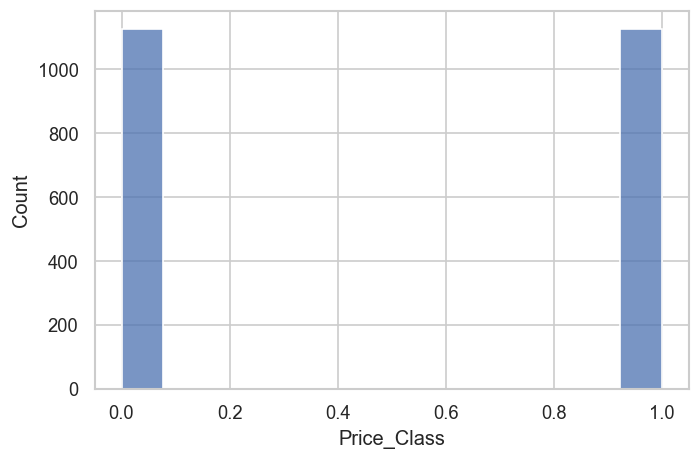

In [107]:
# ======================
# Target distribution
# ======================
target_col = "Price_Class"
X = df.drop(columns=["Price", "Price_Class"])
y = df[target_col]

print("/nTarget value counts:")
print(df[target_col].value_counts())

print("/nTarget distribution (normalized):")
print(df[target_col].value_counts(normalize=True))
sns.histplot(x=target_col,data=df)


In [108]:
# ===================================
# Find Numerical & Categorical Columns
# We assume target column is 'Car'
# ===================================

numeric_cols = X.select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
print("Numeric columns:",numeric_cols)
print("Categorical columns:",categorical_cols)

Numeric columns: ['Car ID', 'Year', 'Engine Size', 'Mileage']
Categorical columns: ['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model']


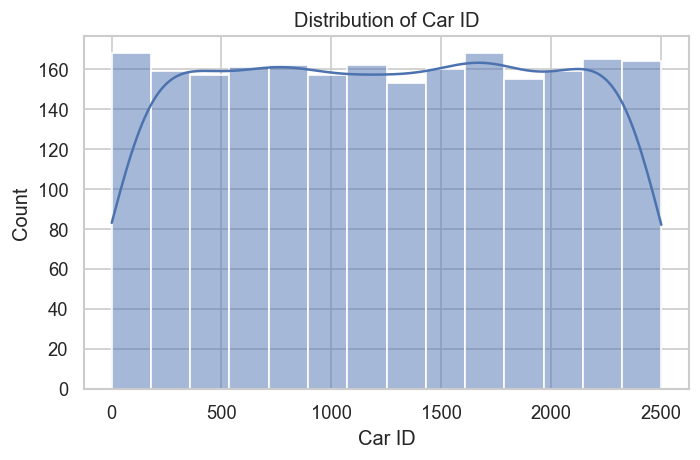

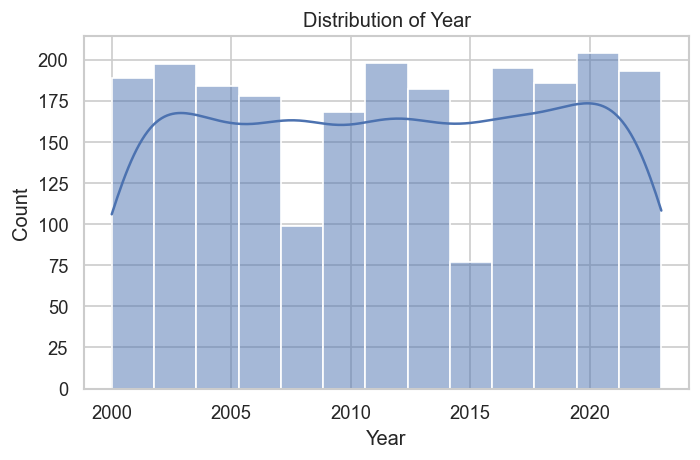

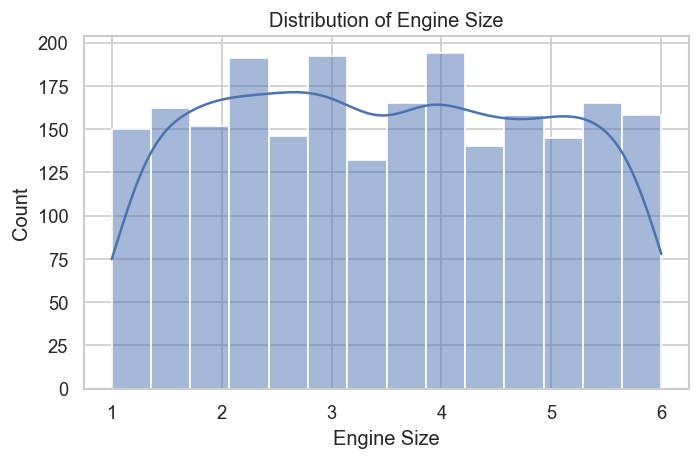

In [113]:
# =================
# Key Distribution
# =================
key_numeric = ["Car ID","Year","Engine Size"]
for col in key_numeric:
    if col in df.columns:
        plt.figsize=(2,2)
        sns.histplot(df[col].dropna(),kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

In [13]:
df["Price"].dtype

dtype('float64')

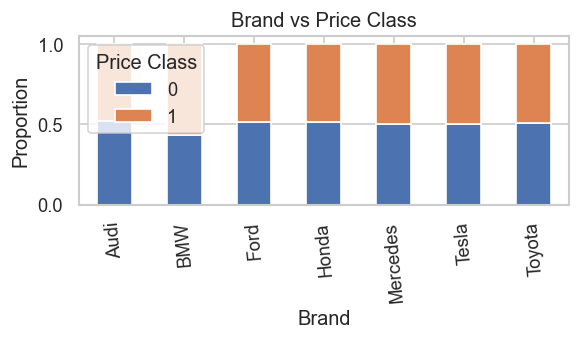

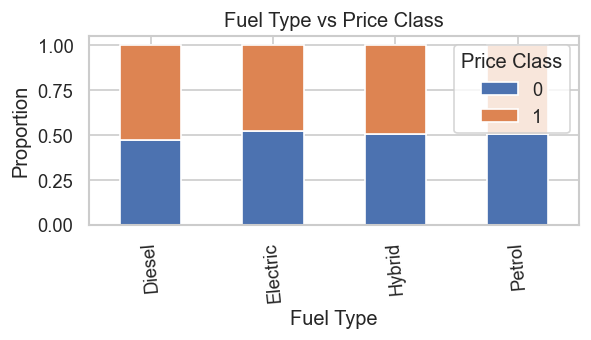

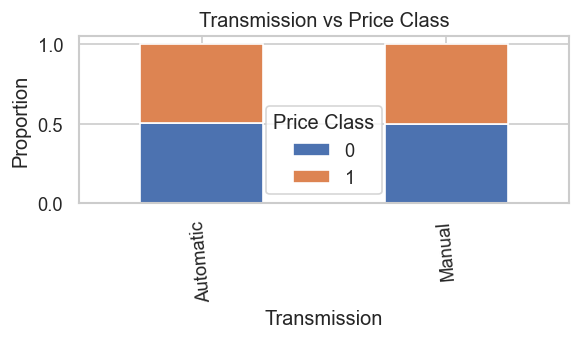

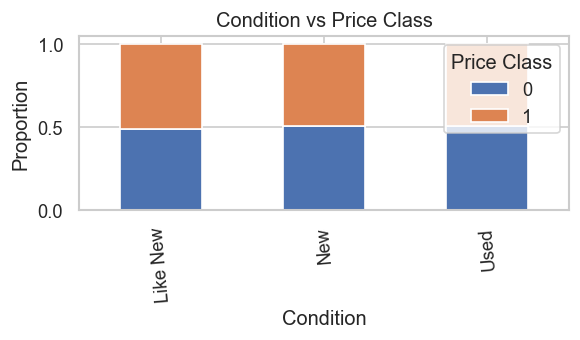

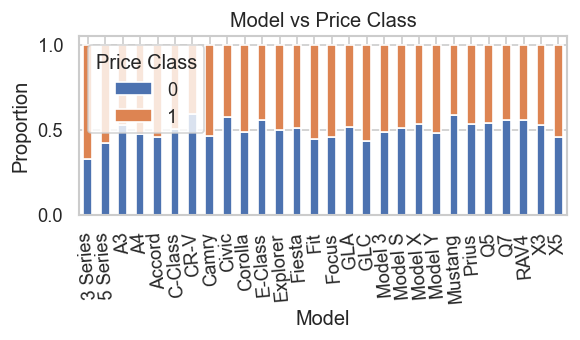

In [31]:
# ======================
# Categorical vs Target
# ======================
cat_to_check = ["Brand","Fuel Type","Transmission","Condition","Model"]
df["Price"] = df["Price"].astype("str")
for col in cat_to_check:
    if col in df.columns:
        ct = pd.crosstab(df[col], df["Price_Class"], normalize="index")

        ct.plot(kind="bar", stacked=True, figsize=(5,3))
        plt.title(f"{col} vs Price Class")
        plt.ylabel("Proportion")
        plt.legend(title="Price Class")
        plt.xticks(rotation=95)
        plt.show()


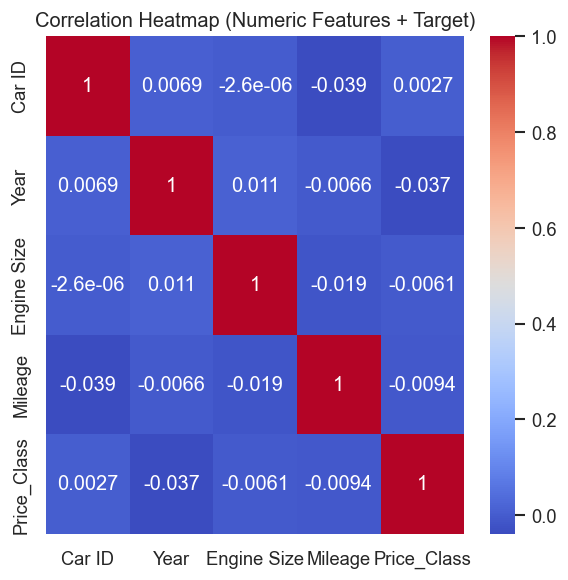

In [32]:
# ===============================================================
# Compute correlation only on numeric columns (including target)
# ===============================================================
numeric_df = df[numeric_cols + [target_col]]
corr = numeric_df.corr()
plt.figure(figsize=(5, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features + Target)")
plt.show()

In [33]:
# =============
# Data Cleaning
# =============
df_clean = df.copy()

# 1. Drop an Car ID column if it exists (it doesn't help prediction)
if " Car ID" in df_clean.columns:
    df_clean = df_clean.drop(columns=["Car ID"])
    print("Dropped 'Car ID' column.")

# 2. Handle 'Mileage' missing values (if present)
if "Mileage" in df_clean.columns:
    print("\nMissing values in Mileage BEFORE:", df_clean["Mileage"].isnull().sum())
    # Convert strings like 'N/A' if present
    df_clean["Mileage"] = pd.to_numeric(df_clean["Mileage"], errors="coerce")
    # Impute with median
    median_bmi = df_clean["Mileage"].median()
    df_clean["Mileage"].fillna(median_bmi, inplace=True)
    print("Missing values in Mileage AFTER:", df_clean["Mileage"].isnull().sum())

# 3. Check duplicates
print("\nNumber of duplicate rows BEFORE:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates()
print("Number of duplicate rows AFTER:", df_clean.duplicated().sum())

print("\nCleaned dataset shape:", df_clean.shape)


Missing values in Mileage BEFORE: 0
Missing values in Mileage AFTER: 0

Number of duplicate rows BEFORE: 0
Number of duplicate rows AFTER: 0

Cleaned dataset shape: (2250, 11)


In [34]:
# =================
# Train/test split
# =================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (1800, 9)
Test set shape: (450, 9)


In [66]:
# ================================
# Preprocessing Pipeline
# ================================
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)


In [69]:
# ================================
# Models
# ================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(kernel="rbf", probability=True),
    "Naive Bayes": GaussianNB()
}


In [79]:
# ================================
# Training + Evaluation
# ================================
from sklearn.metrics import f1_score
results = {}
pipelines = {}

for name, model in models.items():
    print(f"\n===== Training {name} =====")
    
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1 Score": f1_score(y_test, y_pred, average="weighted")
    }
    
    pipelines[name] = pipe
# ================================
# Results Table
# ================================
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("F1 Score", ascending=False)
results_df


===== Training Logistic Regression =====

===== Training KNN =====

===== Training Decision Tree =====

===== Training Random Forest =====

===== Training SVM =====

===== Training Naive Bayes =====


,Accuracy,Precision,Recall,F1 Score
Random Forest,0.542222,0.541913,0.542222,0.541896
Decision Tree,0.540000,0.540247,0.540000,0.540057
KNN,0.531111,0.531065,0.531111,0.531086
SVM,0.526667,0.527364,0.526667,0.526576
Logistic Regression,0.508889,0.509767,0.508889,0.508600
Naive Bayes,0.504444,0.505304,0.504444,0.504153


In [80]:
print(results_df.head())
print(results_df.columns)

                     Accuracy  Precision    Recall  F1 Score
Random Forest        0.542222   0.541913  0.542222  0.541896
Decision Tree        0.540000   0.540247  0.540000  0.540057
KNN                  0.531111   0.531065  0.531111  0.531086
SVM                  0.526667   0.527364  0.526667  0.526576
Logistic Regression  0.508889   0.509767  0.508889  0.508600
Index(['Accuracy', 'Precision', 'Recall', 'F1 Score'], dtype='object')


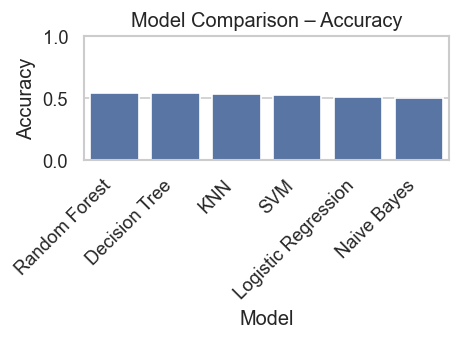

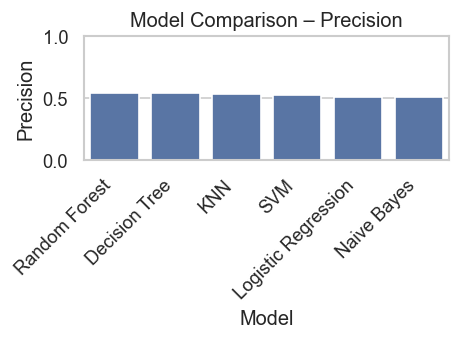

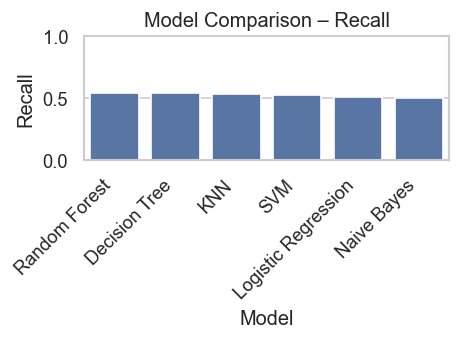

In [81]:
# ======================
# Index → column convert
# ======================
results_df = results_df.reset_index()
results_df = results_df.rename(columns={"index": "Model"})

metrics_to_plot = ["Accuracy", "Precision", "Recall"]

for metric in metrics_to_plot:
    plt.figure(figsize=(4,3))
    sns.barplot(x="Model", y=metric, data=results_df)
    plt.title(f"Model Comparison – {metric}")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0,1)
    plt.show()


In [83]:
# =========================
# Pick best model by Recall
# =========================
best_model_name = results_df.iloc[0]["Model"]
print("Best model by Recall:", best_model_name)

best_pipeline = pipelines[best_model_name]

# Predictions
y_pred_best = best_pipeline.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=["No Stroke", "Stroke"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
cm

Best model by Recall: Random Forest

Classification Report:
              precision    recall  f1-score   support

   No Stroke       0.55      0.57      0.56       230
      Stroke       0.53      0.51      0.52       220

    accuracy                           0.54       450
   macro avg       0.54      0.54      0.54       450
weighted avg       0.54      0.54      0.54       450



array([[131,  99],
       [107, 113]])

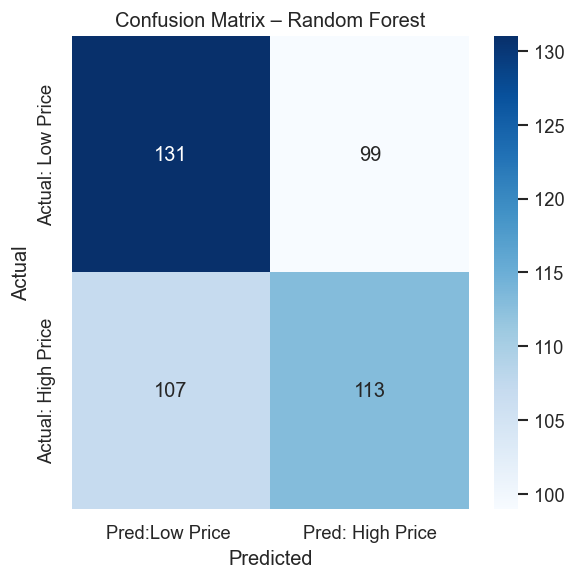

In [115]:
# ======================
# Plot confusion matrix
# ======================
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred:Low Price ", "Pred: High Price"],
            yticklabels=["Actual: Low Price", "Actual: High Price"])
plt.title(f"Confusion Matrix – {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [99]:
import joblib

# Best model based on Recall
best_model_name = "Random Forest"

best_pipeline = pipelines[best_model_name]

# Save model
joblib.dump(best_pipeline, "Car_Price_Prediction.joblib")

print("Random Forest saved successfully as Car_Price_Prediction.joblib")

Random Forest saved successfully as Car_Price_Prediction.joblib


In [101]:
import joblib

# Load model
loaded_model = joblib.load("Car_Price_Prediction.joblib")

# Test prediction
sample_data = X_test.iloc[:5]
predictions = loaded_model.predict(sample_data)
probabilities = loaded_model.predict_proba(sample_data)

print("Predictions:", predictions)
print("Probabilities:", probabilities)

Predictions: [1 1 0 0 0]
Probabilities: [[0.32 0.68]
 [0.31 0.69]
 [0.53 0.47]
 [0.73 0.27]
 [0.55 0.45]]
